In [1]:
import pandas as pd
import numpy as np

# Load datasets
heart_df = pd.read_csv('../data/heart.csv')
diabetes_df = pd.read_csv('../data/diabetes.csv')

# ── HEART DISEASE ──────────────────────────────
print("=" * 50)
print("HEART DISEASE DATASET")
print("=" * 50)
print(f"Shape: {heart_df.shape}")          # rows x columns
print(f"\nFirst 5 rows:")
print(heart_df.head())
print(f"\nColumn Names: {list(heart_df.columns)}")
print(f"\nData Types:\n{heart_df.dtypes}")
print(f"\nMissing Values:\n{heart_df.isnull().sum()}")
print(f"\nTarget Distribution:\n{heart_df['target'].value_counts()}")

# ── DIABETES ───────────────────────────────────
print("\n" + "=" * 50)
print("DIABETES DATASET")
print("=" * 50)
print(f"Shape: {diabetes_df.shape}")
print(f"\nFirst 5 rows:")
print(diabetes_df.head())
print(f"\nMissing Values:\n{diabetes_df.isnull().sum()}")
print(f"\nTarget Distribution:\n{diabetes_df['Outcome'].value_counts()}")

HEART DISEASE DATASET
Shape: (1025, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Column Names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         i

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("HEART DISEASE - Statistical Summary")
print(heart_df.describe().round(2))

print("\nDIABETES - Statistical Summary")
print(diabetes_df.describe().round(2))

HEART DISEASE - Statistical Summary
           age      sex       cp  trestbps     chol      fbs  restecg  \
count  1025.00  1025.00  1025.00   1025.00  1025.00  1025.00  1025.00   
mean     54.43     0.70     0.94    131.61   246.00     0.15     0.53   
std       9.07     0.46     1.03     17.52    51.59     0.36     0.53   
min      29.00     0.00     0.00     94.00   126.00     0.00     0.00   
25%      48.00     0.00     0.00    120.00   211.00     0.00     0.00   
50%      56.00     1.00     1.00    130.00   240.00     0.00     1.00   
75%      61.00     1.00     2.00    140.00   275.00     0.00     1.00   
max      77.00     1.00     3.00    200.00   564.00     1.00     2.00   

       thalach    exang  oldpeak    slope       ca     thal   target  
count  1025.00  1025.00  1025.00  1025.00  1025.00  1025.00  1025.00  
mean    149.11     0.34     1.07     1.39     0.75     2.32     0.51  
std      23.01     0.47     1.18     0.62     1.03     0.62     0.50  
min      71.00     0.0

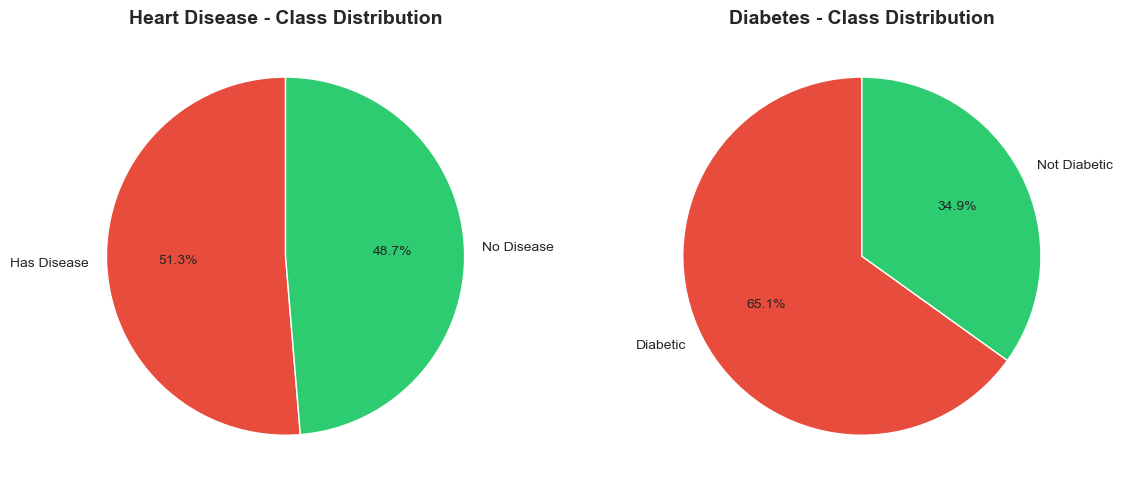

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heart Disease
heart_counts = heart_df['target'].value_counts()
axes[0].pie(heart_counts,
            labels=['Has Disease', 'No Disease'],
            autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'],
            startangle=90)
axes[0].set_title('Heart Disease - Class Distribution', fontsize=14, fontweight='bold')

# Diabetes
diabetes_counts = diabetes_df['Outcome'].value_counts()
axes[1].pie(diabetes_counts,
            labels=['Diabetic', 'Not Diabetic'],
            autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'],
            startangle=90)
axes[1].set_title('Diabetes - Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

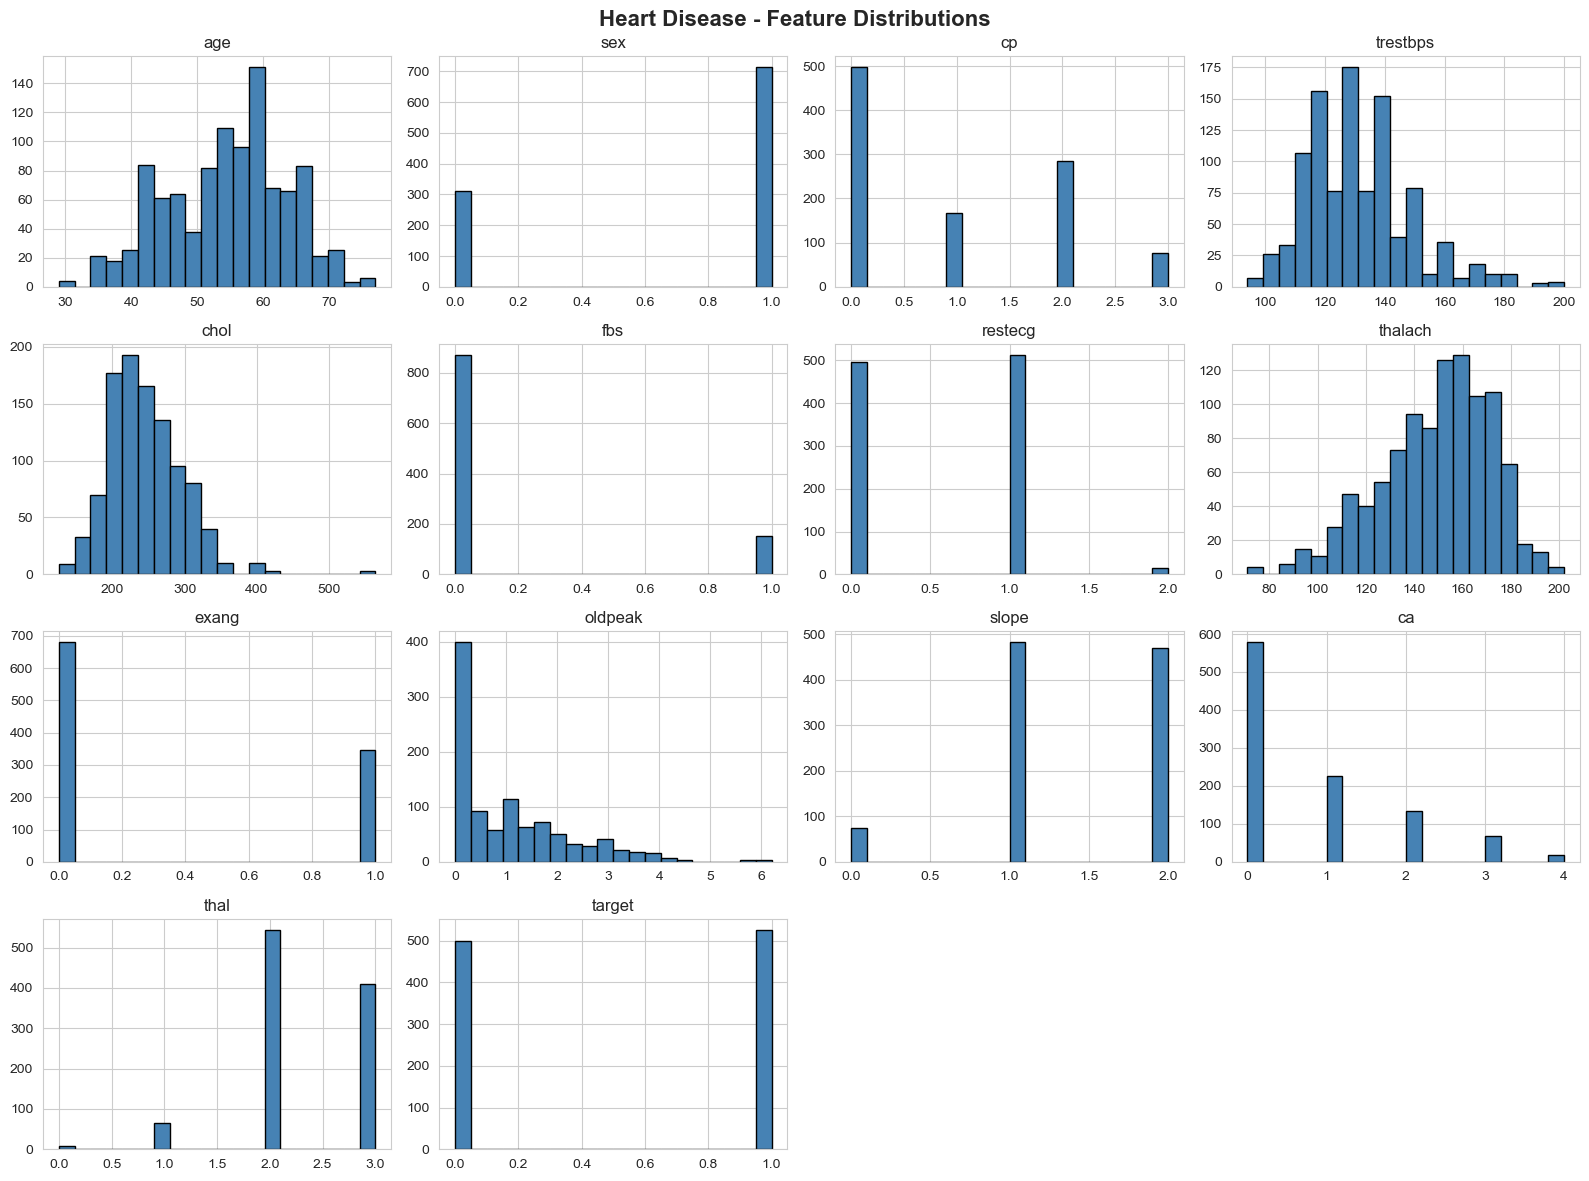

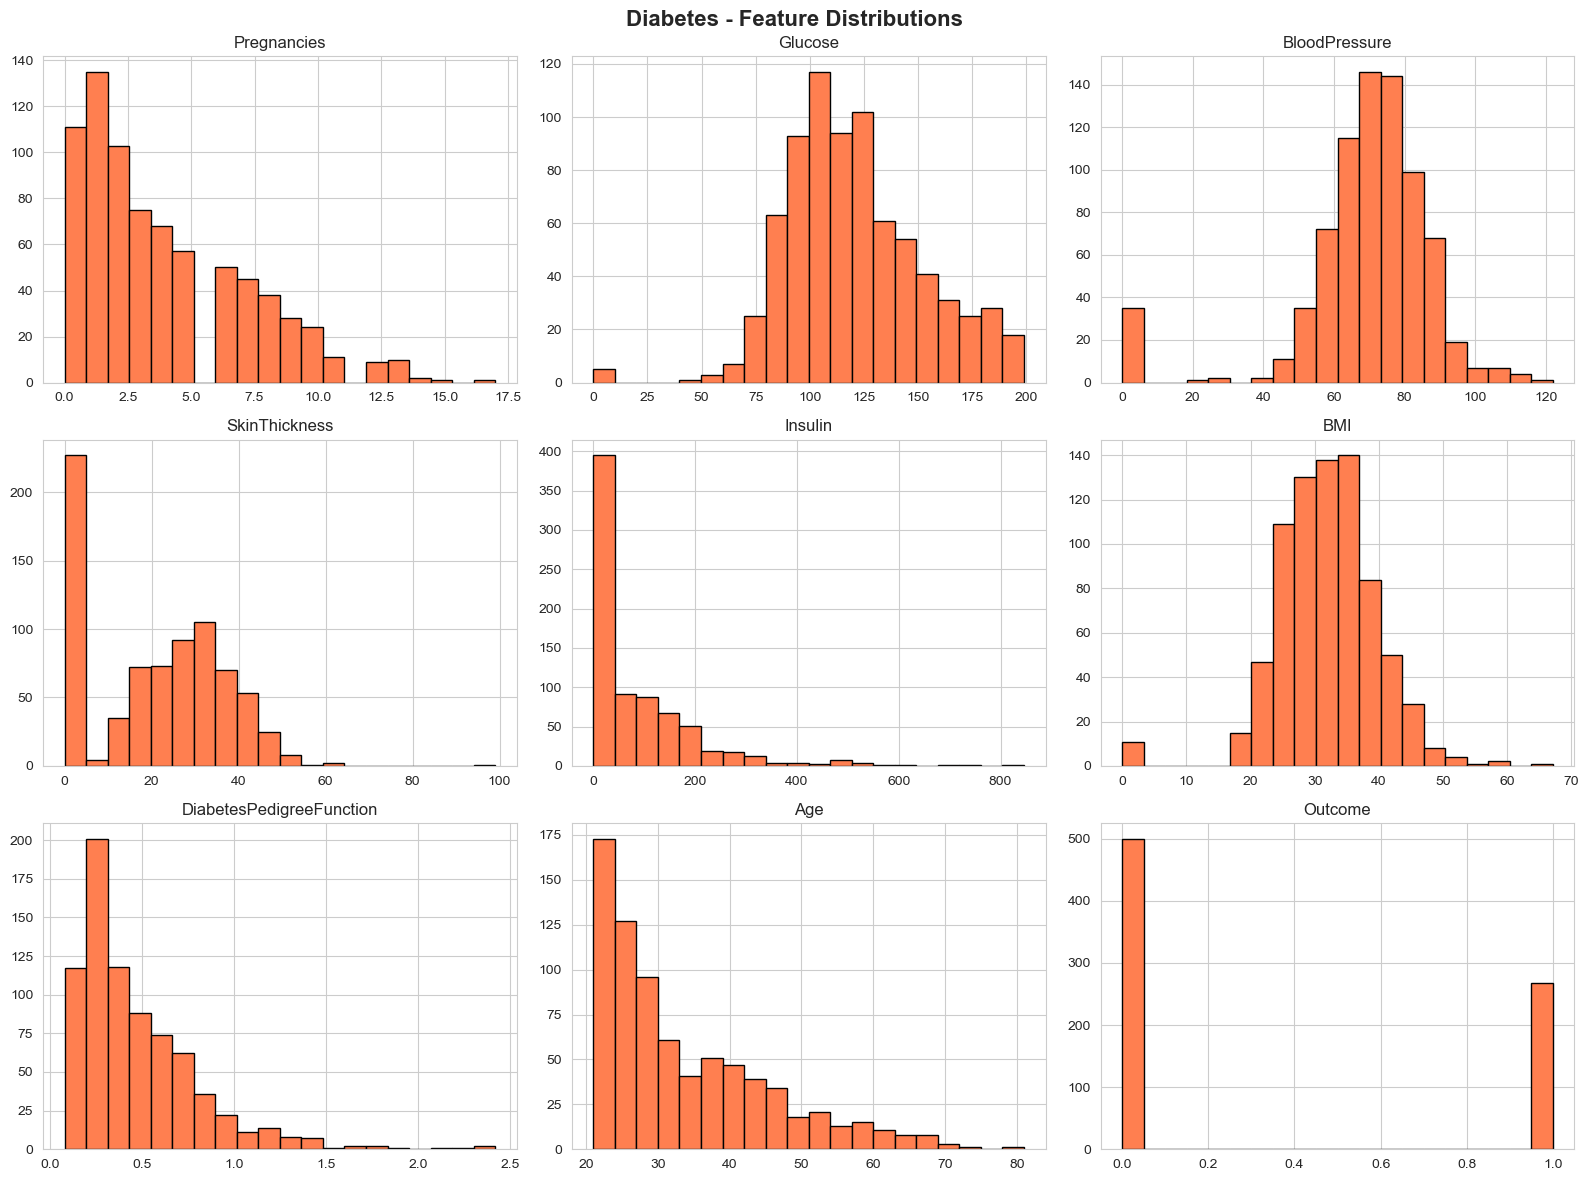

In [7]:
# Heart Disease
heart_df.hist(bins=20, figsize=(16, 12),
              color='steelblue', edgecolor='black')
plt.suptitle('Heart Disease - Feature Distributions',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Diabetes
diabetes_df.hist(bins=20, figsize=(16, 12),
                 color='coral', edgecolor='black')
plt.suptitle('Diabetes - Feature Distributions',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Zeros that are medically impossible = hidden missing values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Hidden Missing Values (zeros that shouldn't be zero):")
print("-" * 50)
for col in zero_cols:
    zero_count = (diabetes_df[col] == 0).sum()
    pct = (zero_count / len(diabetes_df)) * 100
    print(f"{col:20s}: {zero_count:3d} zeros ({pct:.1f}%)")

Hidden Missing Values (zeros that shouldn't be zero):
--------------------------------------------------
Glucose             :   5 zeros (0.7%)
BloodPressure       :  35 zeros (4.6%)
SkinThickness       : 227 zeros (29.6%)
Insulin             : 374 zeros (48.7%)
BMI                 :  11 zeros (1.4%)


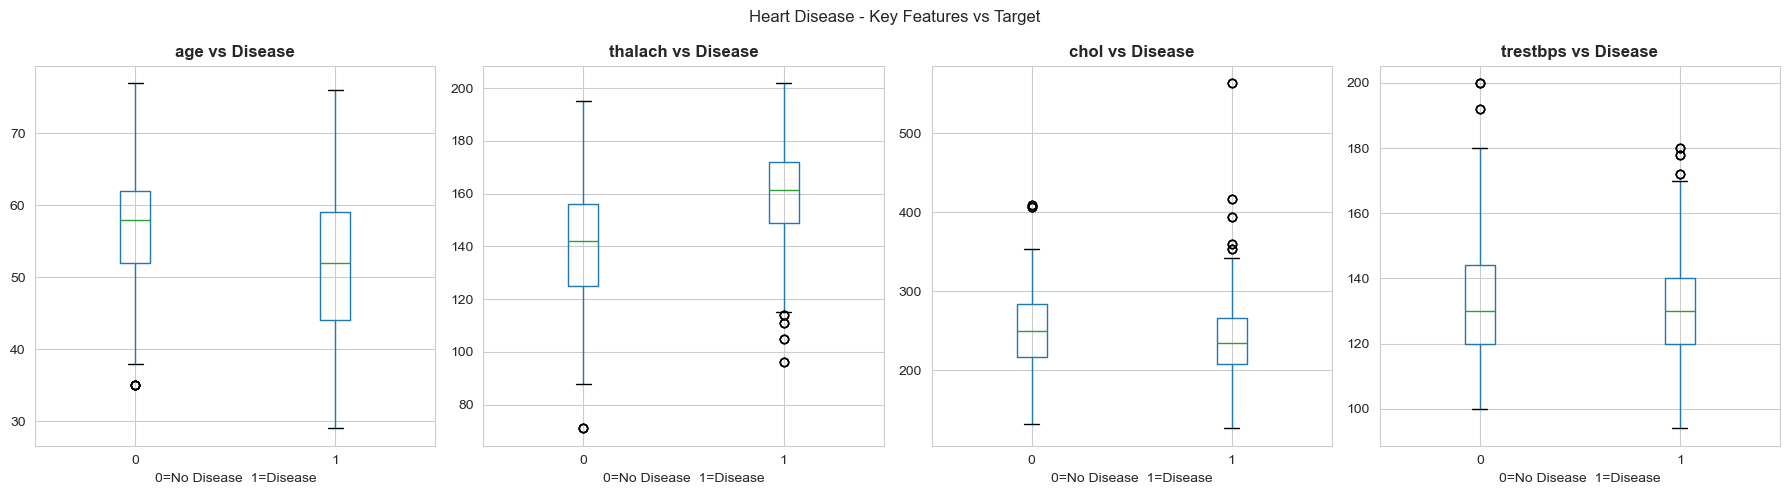

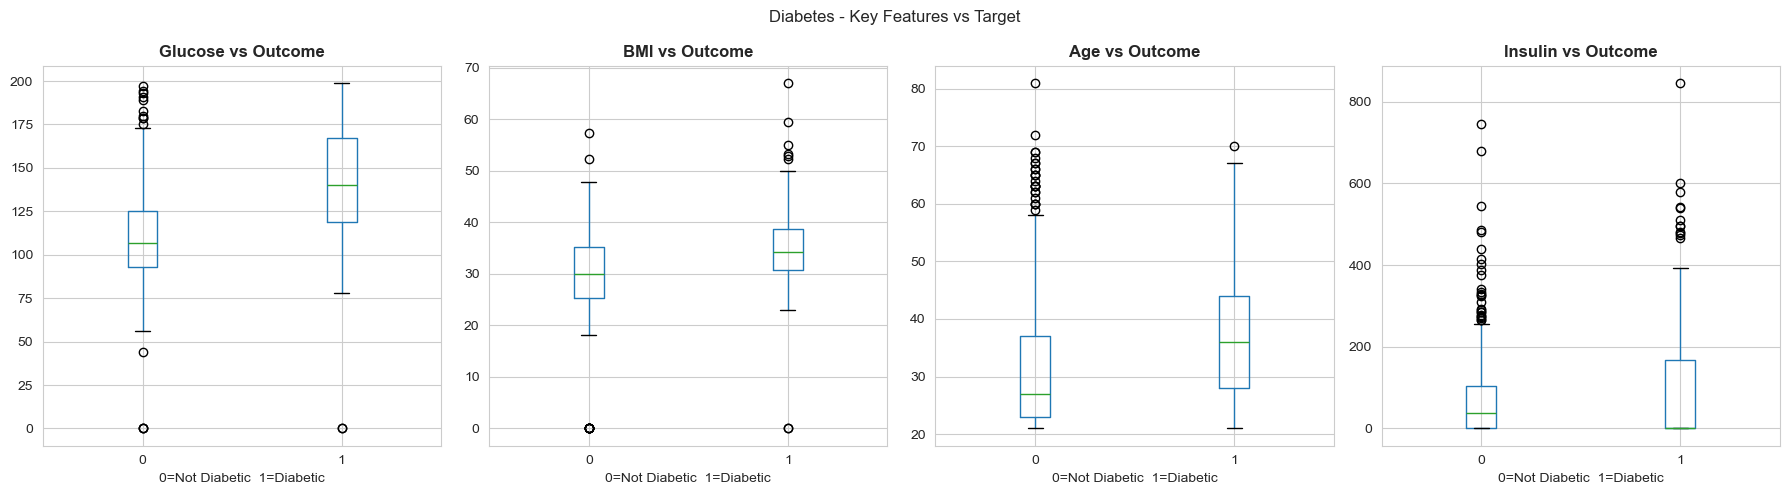

In [9]:
# Heart Disease
heart_features = ['age', 'thalach', 'chol', 'trestbps']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(heart_features):
    heart_df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(f'{col} vs Disease', fontweight='bold')
    axes[i].set_xlabel('0=No Disease  1=Disease')
plt.suptitle('Heart Disease - Key Features vs Target')
plt.tight_layout()
plt.show()

# Diabetes
diabetes_features = ['Glucose', 'BMI', 'Age', 'Insulin']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(diabetes_features):
    diabetes_df.boxplot(column=col, by='Outcome', ax=axes[i])
    axes[i].set_title(f'{col} vs Outcome', fontweight='bold')
    axes[i].set_xlabel('0=Not Diabetic  1=Diabetic')
plt.suptitle('Diabetes - Key Features vs Target')
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np

# Make copies so original data stays intact — always good practice
heart = heart_df.copy()
diabetes = diabetes_df.copy()

# Columns with impossible zeros in diabetes
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN first, then fill with MEDIAN grouped by Outcome
# Why median? Because median is robust to outliers unlike mean
for col in zero_cols:
    diabetes[col] = diabetes[col].replace(0, np.nan)
    diabetes[col] = diabetes[col].fillna(
        diabetes.groupby('Outcome')[col].transform('median')
    )

# Verify no more zeros
print("After fixing — remaining zeros in diabetes:")
for col in zero_cols:
    print(f"  {col:20s}: {(diabetes[col] == 0).sum()} zeros remaining")

print("\nAny NaN values left?")
print(diabetes.isnull().sum())

After fixing — remaining zeros in diabetes:
  Glucose             : 0 zeros remaining
  BloodPressure       : 0 zeros remaining
  SkinThickness       : 0 zeros remaining
  Insulin             : 0 zeros remaining
  BMI                 : 0 zeros remaining

Any NaN values left?
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [11]:
# Visualize outliers using IQR method
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

print("HEART DISEASE - Outlier Summary:")
print("-" * 50)
for col in heart.select_dtypes(include=np.number).columns:
    count, low, high = detect_outliers_iqr(heart, col)
    if count > 0:
        print(f"  {col:15s}: {count} outliers | valid range: [{low:.1f}, {high:.1f}]")

print("\nDIABETES - Outlier Summary:")
print("-" * 50)
for col in diabetes.select_dtypes(include=np.number).columns:
    count, low, high = detect_outliers_iqr(diabetes, col)
    if count > 0:
        print(f"  {col:15s}: {count} outliers | valid range: [{low:.1f}, {high:.1f}]")

HEART DISEASE - Outlier Summary:
--------------------------------------------------
  trestbps       : 30 outliers | valid range: [90.0, 170.0]
  chol           : 16 outliers | valid range: [115.0, 371.0]
  fbs            : 153 outliers | valid range: [0.0, 0.0]
  thalach        : 4 outliers | valid range: [81.0, 217.0]
  oldpeak        : 7 outliers | valid range: [-2.7, 4.5]
  ca             : 87 outliers | valid range: [-1.5, 2.5]
  thal           : 7 outliers | valid range: [0.5, 4.5]

DIABETES - Outlier Summary:
--------------------------------------------------
  Pregnancies    : 4 outliers | valid range: [-6.5, 13.5]
  BloodPressure  : 14 outliers | valid range: [40.0, 104.0]
  SkinThickness  : 87 outliers | valid range: [14.5, 42.5]
  Insulin        : 51 outliers | valid range: [2.0, 270.0]
  BMI            : 8 outliers | valid range: [13.8, 50.2]
  DiabetesPedigreeFunction: 29 outliers | valid range: [-0.3, 1.2]
  Age            : 9 outliers | valid range: [-1.5, 66.5]


In [12]:
# Cap outliers using IQR clipping (Winsorization)
# Why cap instead of remove? Removing rows loses patient data — dangerous in medical ML
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

# Apply to numeric columns (except target)
for col in heart.select_dtypes(include=np.number).columns:
    if col != 'target':
        heart = cap_outliers(heart, col)

for col in diabetes.select_dtypes(include=np.number).columns:
    if col != 'Outcome':
        diabetes = cap_outliers(diabetes, col)

print("✅ Outliers capped successfully!")

✅ Outliers capped successfully!


In [13]:
# ── HEART DISEASE: New Features ─────────────────────────
# Age groups — doctors think in age brackets
heart['age_group'] = pd.cut(heart['age'],
                             bins=[0, 40, 50, 60, 100],
                             labels=['<40', '40-50', '50-60', '60+'])
heart['age_group'] = heart['age_group'].astype(str)

# High cholesterol flag (medical threshold: >200 is borderline)
heart['high_chol'] = (heart['chol'] > 200).astype(int)

# High blood pressure flag (medical threshold: >130)
heart['high_bp'] = (heart['trestbps'] > 130).astype(int)

# Heart rate reserve — difference between max and resting HR
# Lower reserve = heart working harder = higher risk
heart['hr_reserve'] = heart['thalach'] - heart['trestbps']

print("Heart Disease — New Features Added:")
print(heart[['age_group', 'high_chol', 'high_bp', 'hr_reserve']].head())


# ── DIABETES: New Features ───────────────────────────────
# BMI category (WHO standard)
diabetes['bmi_category'] = pd.cut(diabetes['BMI'],
                                   bins=[0, 18.5, 24.9, 29.9, 100],
                                   labels=['Underweight', 'Normal',
                                           'Overweight', 'Obese'])
diabetes['bmi_category'] = diabetes['bmi_category'].astype(str)

# Glucose-Insulin ratio — insulin resistance indicator
diabetes['glucose_insulin_ratio'] = (
    diabetes['Glucose'] / (diabetes['Insulin'] + 1)  # +1 avoids division by zero
)

# Age-risk flag (diabetes risk increases after 45)
diabetes['age_risk'] = (diabetes['Age'] > 45).astype(int)

# Pregnancy risk (high pregnancies + age = higher risk)
diabetes['preg_age_risk'] = diabetes['Pregnancies'] * diabetes['Age']

print("\nDiabetes — New Features Added:")
print(diabetes[['bmi_category', 'glucose_insulin_ratio',
                'age_risk', 'preg_age_risk']].head())

Heart Disease — New Features Added:
  age_group  high_chol  high_bp  hr_reserve
0     50-60          1        0          43
1     50-60          1        1          15
2       60+          0        1         -20
3       60+          1        1          13
4       60+          1        1         -32

Diabetes — New Features Added:
  bmi_category  glucose_insulin_ratio  age_risk  preg_age_risk
0        Obese               0.868035         1          300.0
1   Overweight               0.821256         0           31.0
2       Normal               1.073314         0          256.0
3   Overweight               0.936842         0           21.0
4        Obese               0.810651         0            0.0


In [14]:
# One-hot encode the string categories we created
heart = pd.get_dummies(heart, columns=['age_group'], drop_first=True)
diabetes = pd.get_dummies(diabetes, columns=['bmi_category'], drop_first=True)

print("Heart shape after encoding:", heart.shape)
print("Diabetes shape after encoding:", diabetes.shape)

Heart shape after encoding: (1025, 20)
Diabetes shape after encoding: (768, 15)


In [15]:
# ── HEART ────────────────────────────────────
X_heart = heart.drop('target', axis=1)
y_heart = heart['target']

# ── DIABETES ─────────────────────────────────
X_diabetes = diabetes.drop('Outcome', axis=1)
y_diabetes = diabetes['Outcome']

print("Heart    → X:", X_heart.shape, " y:", y_heart.shape)
print("Diabetes → X:", X_diabetes.shape, " y:", y_diabetes.shape)

Heart    → X: (1025, 19)  y: (1025,)
Diabetes → X: (768, 14)  y: (768,)


In [16]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
# stratify=y ensures class balance is preserved in both splits
X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(
    X_heart, y_heart,
    test_size=0.2,
    random_state=42,
    stratify=y_heart        # ← very important for medical data
)

X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diabetes, y_diabetes,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes
)

print("Heart    → Train:", X_heart_train.shape, "| Test:", X_heart_test.shape)
print("Diabetes → Train:", X_diab_train.shape,  "| Test:", X_diab_test.shape)

Heart    → Train: (820, 19) | Test: (205, 19)
Diabetes → Train: (614, 14) | Test: (154, 14)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler_heart = StandardScaler()
scaler_diabetes = StandardScaler()

# Fit ONLY on training data, transform both train and test
# Why? Fitting on test data = data leakage — the model "sees" the future
X_heart_train_sc = scaler_heart.fit_transform(X_heart_train)
X_heart_test_sc  = scaler_heart.transform(X_heart_test)

X_diab_train_sc  = scaler_diabetes.fit_transform(X_diab_train)
X_diab_test_sc   = scaler_diabetes.transform(X_diab_test)

print("✅ Scaling complete!")
print("Heart train sample (first row, first 5 features):")
print(X_heart_train_sc[0][:5])

✅ Scaling complete!
Heart train sample (first row, first 5 features):
[ 0.81162633 -1.50996689 -0.90957214  0.36180722  0.97995748]


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              classification_report)
import warnings
warnings.filterwarnings('ignore')

# Define all 5 models with good default parameters
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # handles class imbalance
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,          # needed for ROC-AUC score
        random_state=42
    )
}

print("✅ Models defined:", list(models.keys()))

✅ Models defined: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'SVM']


In [19]:
# Reusable function to evaluate any model
# Why a function? Clean code, reusable for both datasets
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability for ROC-AUC
    
    # Metrics
    results = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob) * 100, 2)
    }
    return results, model

print("✅ Evaluation function ready!")

✅ Evaluation function ready!


In [20]:
print("=" * 60)
print("TRAINING MODELS — HEART DISEASE")
print("=" * 60)

heart_results = []
heart_trained_models = {}

for name, model in models.items():
    print(f"  Training {name}...", end=' ')
    result, trained_model = evaluate_model(
        name, model,
        X_heart_train_sc, X_heart_test_sc,
        y_heart_train, y_heart_test
    )
    heart_results.append(result)
    heart_trained_models[name] = trained_model
    print(f"✅ Accuracy: {result['Accuracy']}% | F1: {result['F1 Score']}% | ROC-AUC: {result['ROC-AUC']}%")

# Results table
heart_results_df = pd.DataFrame(heart_results).sort_values('ROC-AUC', ascending=False)
heart_results_df = heart_results_df.reset_index(drop=True)
heart_results_df.index += 1  # rank starts from 1

print("\n📊 HEART DISEASE — MODEL COMPARISON:")
print(heart_results_df.to_string())

TRAINING MODELS — HEART DISEASE
  Training Logistic Regression... ✅ Accuracy: 86.83% | F1: 87.67% | ROC-AUC: 93.45%
  Training Random Forest... ✅ Accuracy: 100.0% | F1: 100.0% | ROC-AUC: 100.0%
  Training XGBoost... ✅ Accuracy: 100.0% | F1: 100.0% | ROC-AUC: 100.0%
  Training LightGBM... ✅ Accuracy: 100.0% | F1: 100.0% | ROC-AUC: 100.0%
  Training SVM... ✅ Accuracy: 92.68% | F1: 92.96% | ROC-AUC: 97.29%

📊 HEART DISEASE — MODEL COMPARISON:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1        Random Forest    100.00     100.00  100.00    100.00   100.00
2              XGBoost    100.00     100.00  100.00    100.00   100.00
3             LightGBM    100.00     100.00  100.00    100.00   100.00
4                  SVM     92.68      91.67   94.29     92.96    97.29
5  Logistic Regression     86.83      84.21   91.43     87.67    93.45


In [21]:
print("=" * 60)
print("TRAINING MODELS — DIABETES")
print("=" * 60)

diabetes_results = []
diabetes_trained_models = {}

for name, model in models.items():
    print(f"  Training {name}...", end=' ')
    result, trained_model = evaluate_model(
        name, model,
        X_diab_train_sc, X_diab_test_sc,
        y_diab_train, y_diab_test
    )
    diabetes_results.append(result)
    diabetes_trained_models[name] = trained_model
    print(f"✅ Accuracy: {result['Accuracy']}% | F1: {result['F1 Score']}% | ROC-AUC: {result['ROC-AUC']}%")

# Results table
diabetes_results_df = pd.DataFrame(diabetes_results).sort_values('ROC-AUC', ascending=False)
diabetes_results_df = diabetes_results_df.reset_index(drop=True)
diabetes_results_df.index += 1

print("\n📊 DIABETES — MODEL COMPARISON:")
print(diabetes_results_df.to_string())

TRAINING MODELS — DIABETES
  Training Logistic Regression... ✅ Accuracy: 77.92% | F1: 73.02% | ROC-AUC: 84.69%
  Training Random Forest... ✅ Accuracy: 85.71% | F1: 78.43% | ROC-AUC: 94.08%
  Training XGBoost... ✅ Accuracy: 88.31% | F1: 83.33% | ROC-AUC: 95.31%
  Training LightGBM... ✅ Accuracy: 87.66% | F1: 82.24% | ROC-AUC: 95.15%
  Training SVM... ✅ Accuracy: 85.06% | F1: 79.65% | ROC-AUC: 90.67%

📊 DIABETES — MODEL COMPARISON:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1              XGBoost     88.31      83.33   83.33     83.33    95.31
2             LightGBM     87.66      83.02   81.48     82.24    95.15
3        Random Forest     85.71      83.33   74.07     78.43    94.08
4                  SVM     85.06      76.27   83.33     79.65    90.67
5  Logistic Regression     77.92      63.89   85.19     73.02    84.69


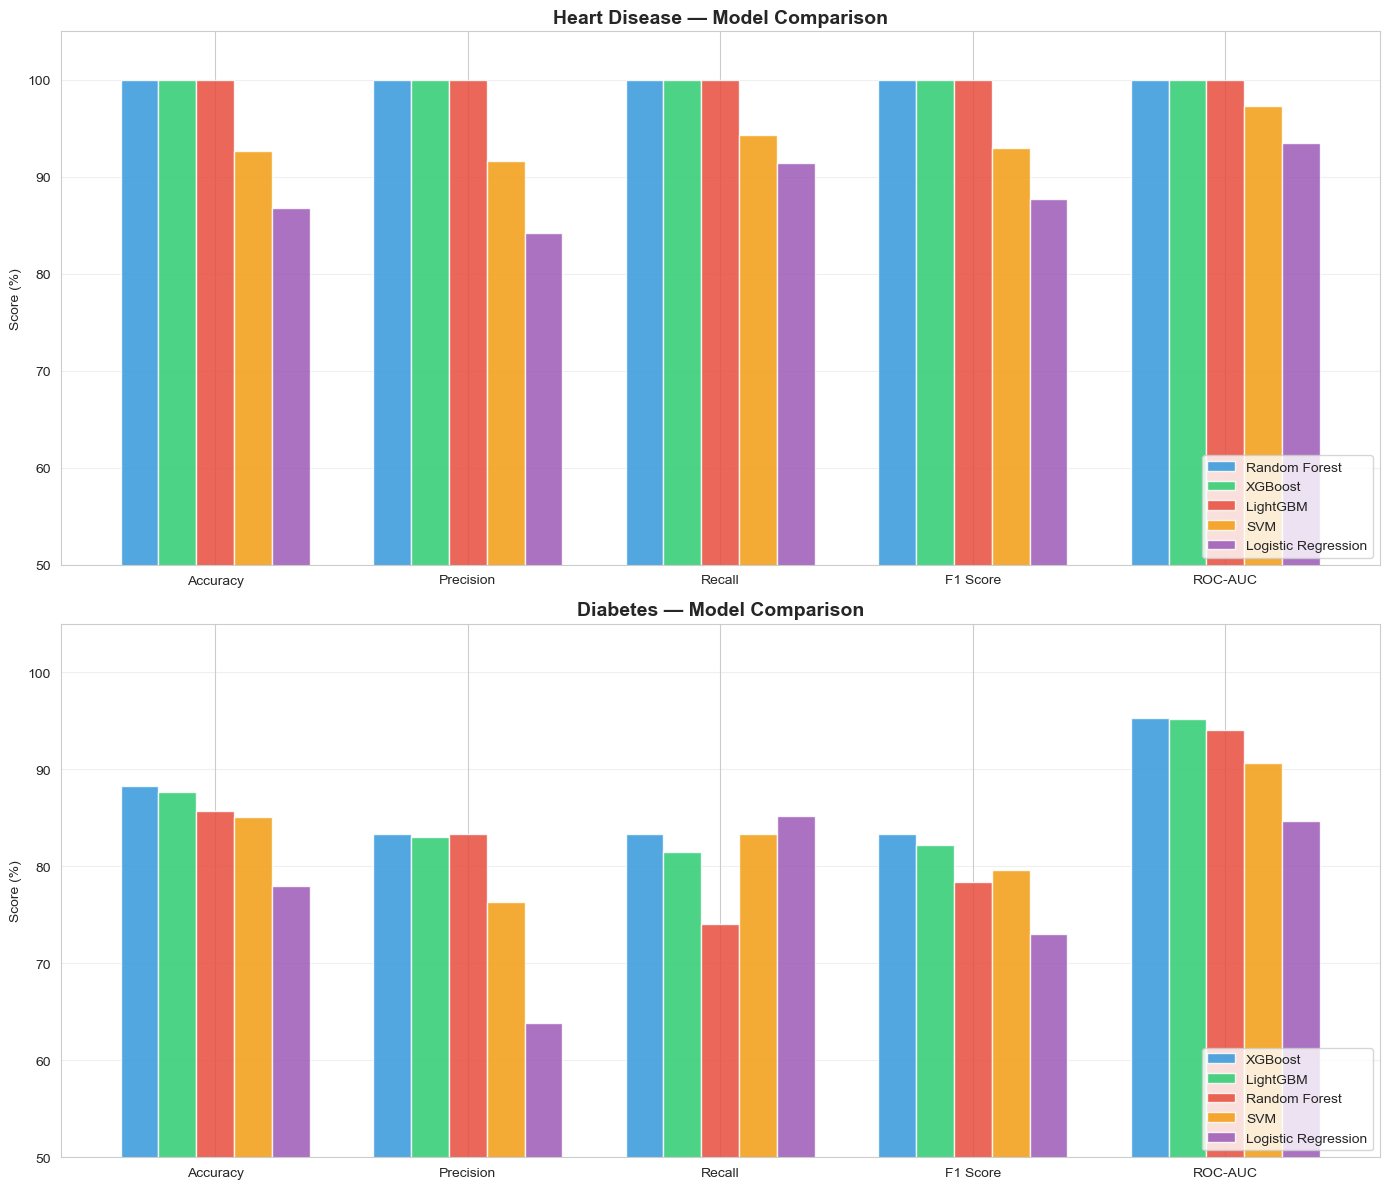

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

# ── Heart Disease Plot ──────────────────────────────────
for i, (_, row) in enumerate(heart_results_df.iterrows()):
    axes[0].bar(x + i * width,
                [row[m] for m in metrics],
                width, label=row['Model'],
                color=colors[i], alpha=0.85)

axes[0].set_title('Heart Disease — Model Comparison', 
                   fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(50, 105)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# ── Diabetes Plot ───────────────────────────────────────
for i, (_, row) in enumerate(diabetes_results_df.iterrows()):
    axes[1].bar(x + i * width,
                [row[m] for m in metrics],
                width, label=row['Model'],
                color=colors[i], alpha=0.85)

axes[1].set_title('Diabetes — Model Comparison',
                   fontsize=14, fontweight='bold')
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(50, 105)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150)
plt.show()

Best Heart Model    : Random Forest
Best Diabetes Model : XGBoost

✅ Models retrained on clean arrays!


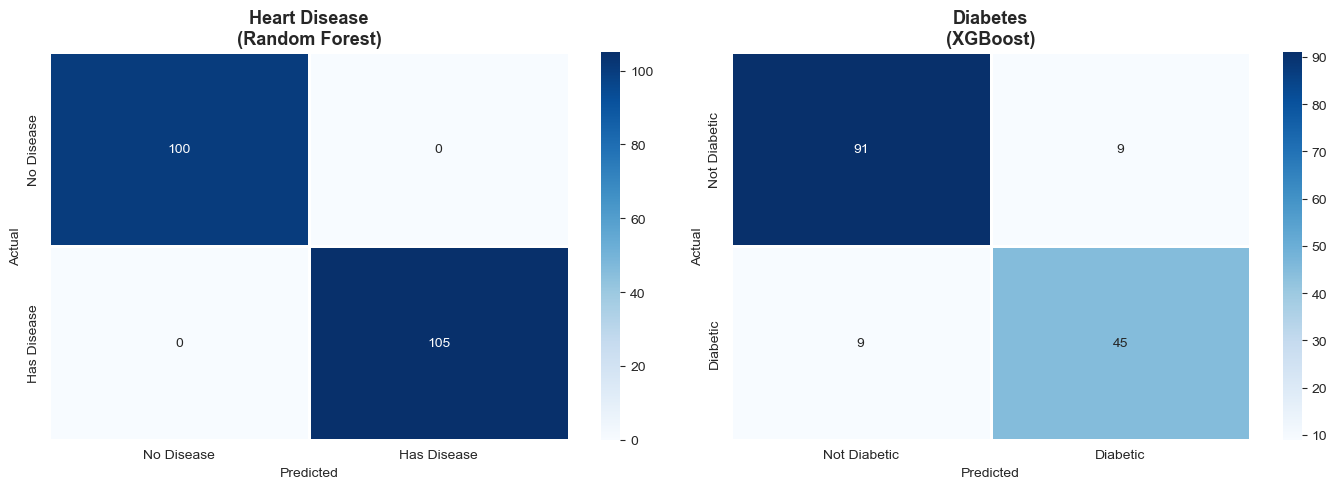

✅ Confusion matrices done!


In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# ── Convert everything to clean float32 numpy arrays ────────
X_heart_train_arr = np.array(X_heart_train_sc, dtype=np.float32)
X_heart_test_arr  = np.array(X_heart_test_sc,  dtype=np.float32)
X_diab_train_arr  = np.array(X_diab_train_sc,  dtype=np.float32)
X_diab_test_arr   = np.array(X_diab_test_sc,   dtype=np.float32)

# ── Retrain best models on clean arrays ─────────────────────
best_heart_name = heart_results_df.iloc[0]['Model']
best_diab_name  = diabetes_results_df.iloc[0]['Model']

print(f"Best Heart Model    : {best_heart_name}")
print(f"Best Diabetes Model : {best_diab_name}")

# Retrain on float32 arrays
best_heart_model = heart_trained_models[best_heart_name]
best_diab_model  = diabetes_trained_models[best_diab_name]

best_heart_model.fit(X_heart_train_arr, y_heart_train)
best_diab_model.fit(X_diab_train_arr,  y_diab_train)

print("\n✅ Models retrained on clean arrays!")

# ── Confusion Matrices ───────────────────────────────────────
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, X_test, y_test, title, labels in [
    (axes[0], best_heart_model,
     X_heart_test_arr, y_heart_test,
     f'Heart Disease\n({best_heart_name})',
     ['No Disease', 'Has Disease']),
    (axes[1], best_diab_model,
     X_diab_test_arr, y_diab_test,
     f'Diabetes\n({best_diab_name})',
     ['Not Diabetic', 'Diabetic'])
]:
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                linewidths=1, linecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrices done!")

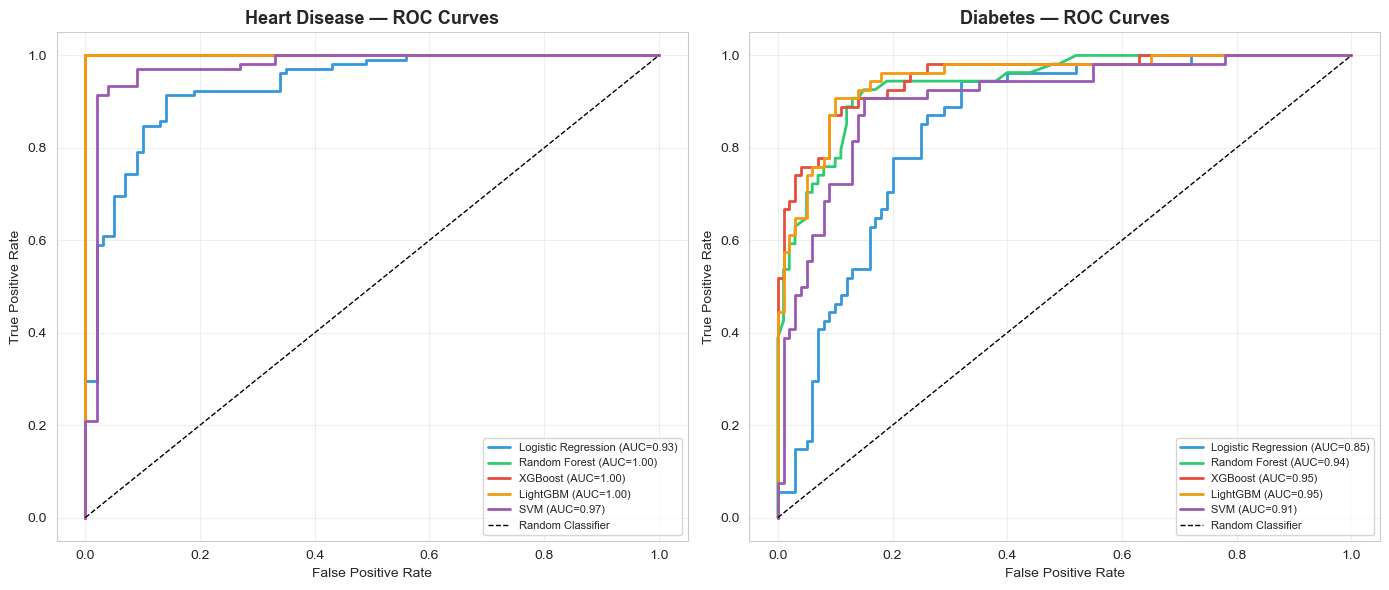

✅ ROC curves done!


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, trained_models, X_train_arr, X_test_arr, y_train, y_test, title in [
    (axes[0], heart_trained_models,
     X_heart_train_arr, X_heart_test_arr,
     y_heart_train, y_heart_test,
     'Heart Disease — ROC Curves'),
    (axes[1], diabetes_trained_models,
     X_diab_train_arr, X_diab_test_arr,
     y_diab_train, y_diab_test,
     'Diabetes — ROC Curves')
]:
    for (name, model), color in zip(trained_models.items(), colors):
        # Retrain each model on clean array
        model.fit(X_train_arr, y_train)
        y_prob = model.predict_proba(X_test_arr)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC={auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=150)
plt.show()
print("✅ ROC curves done!")

In [30]:
print("=" * 50)
print("📋 FINAL SUMMARY")
print("=" * 50)

print("\n🫀 HEART DISEASE — Top 3 Models:")
print(heart_results_df[['Model', 'Recall',
      'F1 Score', 'ROC-AUC']].head(3).to_string())

print("\n🩸 DIABETES — Top 3 Models:")
print(diabetes_results_df[['Model', 'Recall',
      'F1 Score', 'ROC-AUC']].head(3).to_string())

print(f"\n✅ Best model for Heart Disease : {best_heart_name}")
print(f"✅ Best model for Diabetes      : {best_diab_name}")
print("\nThese will be saved in Phase 6 for deployment.")

📋 FINAL SUMMARY

🫀 HEART DISEASE — Top 3 Models:
           Model  Recall  F1 Score  ROC-AUC
1  Random Forest   100.0     100.0    100.0
2        XGBoost   100.0     100.0    100.0
3       LightGBM   100.0     100.0    100.0

🩸 DIABETES — Top 3 Models:
           Model  Recall  F1 Score  ROC-AUC
1        XGBoost   83.33     83.33    95.31
2       LightGBM   81.48     82.24    95.15
3  Random Forest   74.07     78.43    94.08

✅ Best model for Heart Disease : Random Forest
✅ Best model for Diabetes      : XGBoost

These will be saved in Phase 6 for deployment.


In [31]:
import shap
import warnings
import matplotlib.pyplot as plt
import numpy as np
warnings.filterwarnings('ignore')

# Initialize SHAP's JS visualization (needed for notebooks)
shap.initjs()

print("SHAP version:", shap.__version__)
print("✅ SHAP ready!")

SHAP version: 0.51.0
✅ SHAP ready!


In [32]:
print("Computing SHAP values for Heart Disease...")
print("(This may take 30-60 seconds)")

# TreeExplainer is optimized for tree-based models
# like Random Forest, XGBoost, LightGBM
heart_explainer = shap.TreeExplainer(best_heart_model)

# Compute SHAP values on TEST set
# shap_values shape: (n_samples, n_features, n_classes)
heart_shap_values = heart_explainer.shap_values(X_heart_test_arr)

print("✅ SHAP values computed!")
print(f"Shape of SHAP values: {np.array(heart_shap_values).shape}")

# For binary classification Random Forest returns list of 2 arrays
# Index [1] = SHAP values for class 1 (Has Disease)
if isinstance(heart_shap_values, list):
    heart_shap_vals = heart_shap_values[1]
else:
    heart_shap_vals = heart_shap_values

print(f"Using SHAP values shape: {heart_shap_vals.shape}")

Computing SHAP values for Heart Disease...
(This may take 30-60 seconds)
✅ SHAP values computed!
Shape of SHAP values: (205, 19, 2)
Using SHAP values shape: (205, 19, 2)


<Figure size 1000x800 with 0 Axes>

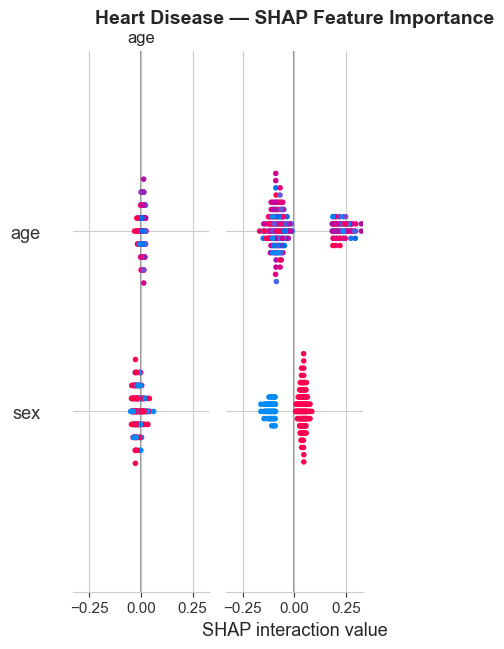

✅ Heart SHAP summary plot saved!


In [33]:
# ── HEART DISEASE: Summary Plot ─────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    heart_shap_vals,
    X_heart_test_arr,
    feature_names=list(X_heart_train.columns),
    plot_type="dot",        # dot plot shows distribution
    show=False
)
plt.title("Heart Disease — SHAP Feature Importance",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/heart_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heart SHAP summary plot saved!")

<Figure size 1000x700 with 0 Axes>

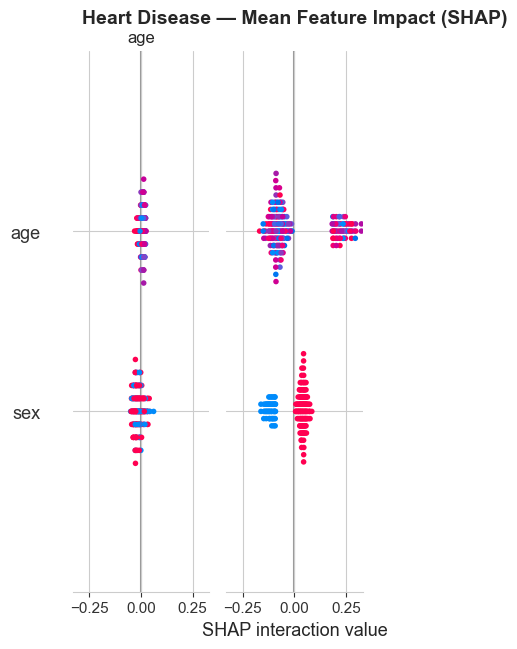

✅ Heart SHAP bar plot saved!


In [34]:
# Bar plot = mean absolute SHAP value per feature
# Easier to read for non-technical stakeholders

plt.figure(figsize=(10, 7))
shap.summary_plot(
    heart_shap_vals,
    X_heart_test_arr,
    feature_names=list(X_heart_train.columns),
    plot_type="bar",
    show=False
)
plt.title("Heart Disease — Mean Feature Impact (SHAP)",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/heart_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heart SHAP bar plot saved!")

Computing SHAP values for Diabetes...
✅ SHAP values computed!
Using SHAP values shape: (154, 14)


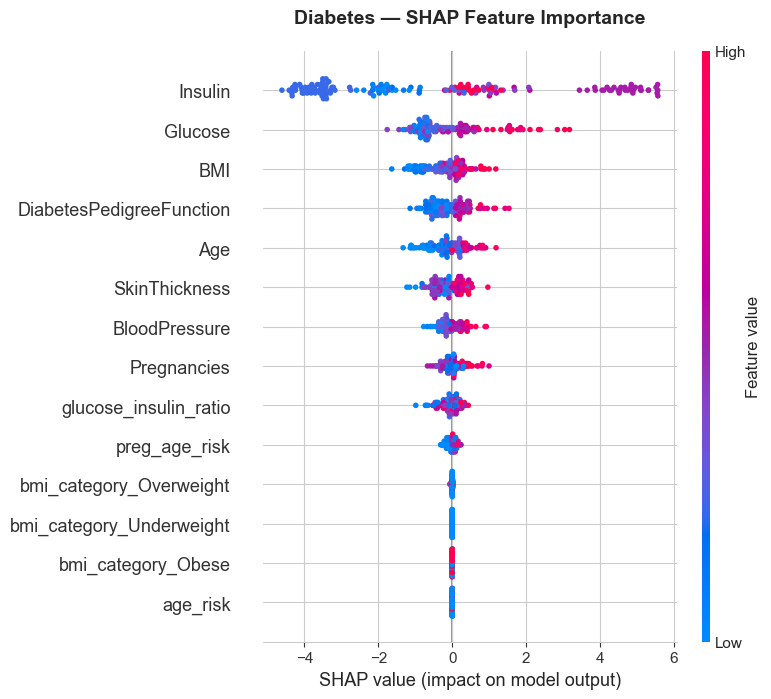

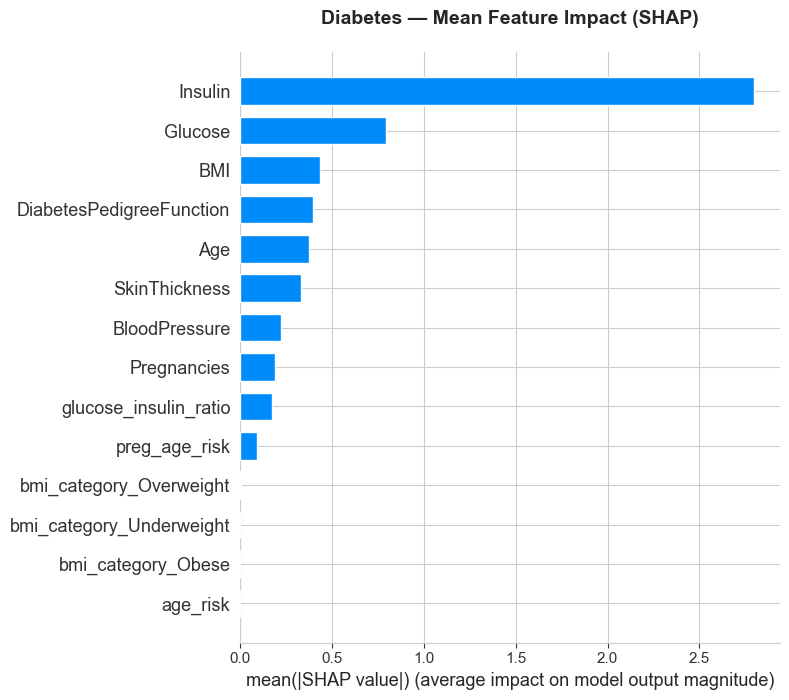

✅ Diabetes SHAP plots saved!


In [35]:
print("Computing SHAP values for Diabetes...")

diabetes_explainer = shap.TreeExplainer(best_diab_model)
diabetes_shap_values = diabetes_explainer.shap_values(X_diab_test_arr)

# XGBoost returns array directly (not list)
if isinstance(diabetes_shap_values, list):
    diabetes_shap_vals = diabetes_shap_values[1]
else:
    diabetes_shap_vals = diabetes_shap_values

print("✅ SHAP values computed!")
print(f"Using SHAP values shape: {diabetes_shap_vals.shape}")

# ── Summary Plot ─────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    diabetes_shap_vals,
    X_diab_test_arr,
    feature_names=list(X_diab_train.columns),
    plot_type="dot",
    show=False
)
plt.title("Diabetes — SHAP Feature Importance",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/diabetes_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar Plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    diabetes_shap_vals,
    X_diab_test_arr,
    feature_names=list(X_diab_train.columns),
    plot_type="bar",
    show=False
)
plt.title("Diabetes — Mean Feature Impact (SHAP)",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/diabetes_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Diabetes SHAP plots saved!")

🫀 HEART DISEASE — Single Patient Explanation
--------------------------------------------------
Actual    : No Disease
Predicted : No Disease
Confidence: 38.0% chance of disease

SHAP values shape: (205, 14, 2)
Expected value   : [0.50232961 0.49767039]
Single patient SHAP shape: (14,)


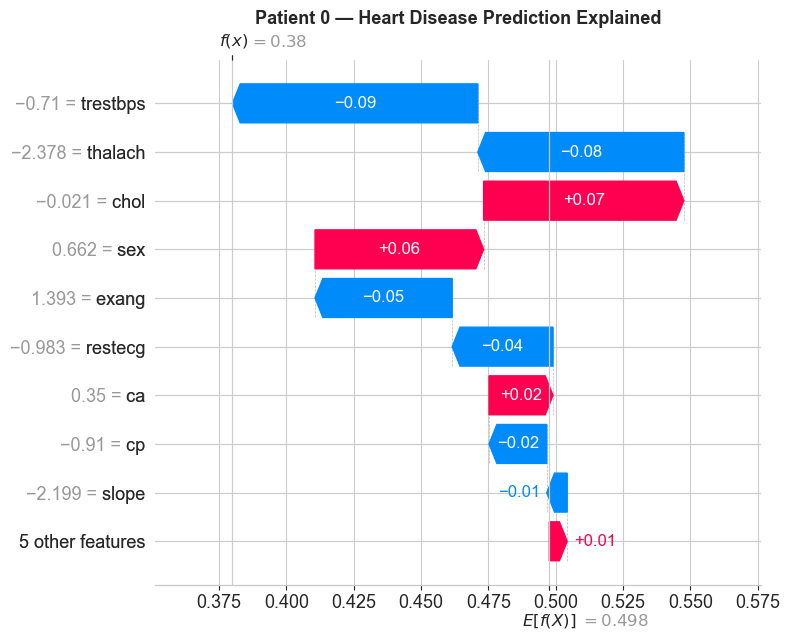

✅ Heart patient explanation done!


In [38]:
patient_idx = 0

print("🫀 HEART DISEASE — Single Patient Explanation")
print("-" * 50)

actual    = y_heart_test.iloc[patient_idx]
predicted = best_heart_model.predict(
                X_heart_test_fixed[patient_idx].reshape(1, -1))[0]
prob      = best_heart_model.predict_proba(
                X_heart_test_fixed[patient_idx].reshape(1, -1))[0][1]

print(f"Actual    : {'Disease' if actual == 1 else 'No Disease'}")
print(f"Predicted : {'Disease' if predicted == 1 else 'No Disease'}")
print(f"Confidence: {prob*100:.1f}% chance of disease")

# Recompute SHAP
heart_explainer2 = shap.TreeExplainer(best_heart_model)

# Get SHAP explanation object directly — most reliable method
heart_explanation = heart_explainer2(X_heart_test_fixed)

# Debug: check shape
print(f"\nSHAP values shape: {heart_explanation.values.shape}")
print(f"Expected value   : {heart_explainer2.expected_value}")

heart_feat_names = list(X_heart_train.columns)[:n_heart_features]

# For binary classification — take class 1 (disease) values
# Shape could be (n_samples, n_features) or (n_samples, n_features, n_classes)
if len(heart_explanation.values.shape) == 3:
    # 3D → take class 1
    shap_vals_single = heart_explanation.values[patient_idx, :, 1]
    base_val = heart_explainer2.expected_value[1]
else:
    # 2D → take directly
    shap_vals_single = heart_explanation.values[patient_idx]
    base_val = heart_explainer2.expected_value
    if isinstance(base_val, list):
        base_val = base_val[1]

print(f"Single patient SHAP shape: {shap_vals_single.shape}")

# Build single Explanation object
single_exp = shap.Explanation(
    values=shap_vals_single,
    base_values=float(base_val),
    data=X_heart_test_fixed[patient_idx],
    feature_names=heart_feat_names
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(single_exp, show=False)
plt.title(f"Patient {patient_idx} — Heart Disease Prediction Explained",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/heart_patient_explanation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heart patient explanation done!")

🩸 DIABETES — Single Patient Explanation
--------------------------------------------------
Actual    : Not Diabetic
Predicted : Not Diabetic
Confidence: 9.2% chance of diabetes

SHAP values shape: (154, 14)


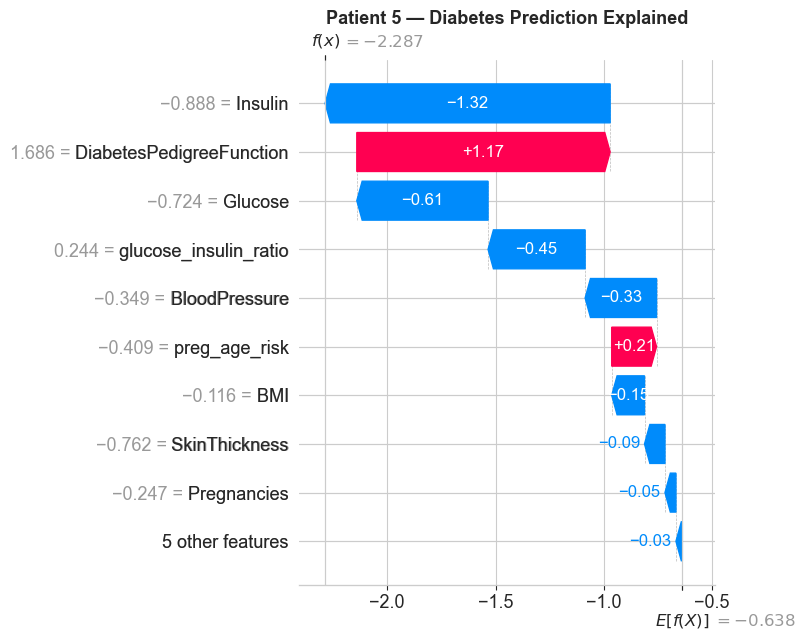

✅ Diabetes patient explanation done!


In [39]:
patient_idx = 5

print("🩸 DIABETES — Single Patient Explanation")
print("-" * 50)

actual    = y_diab_test.iloc[patient_idx]
predicted = best_diab_model.predict(
                X_diab_test_fixed[patient_idx].reshape(1, -1))[0]
prob      = best_diab_model.predict_proba(
                X_diab_test_fixed[patient_idx].reshape(1, -1))[0][1]

print(f"Actual    : {'Diabetic' if actual == 1 else 'Not Diabetic'}")
print(f"Predicted : {'Diabetic' if predicted == 1 else 'Not Diabetic'}")
print(f"Confidence: {prob*100:.1f}% chance of diabetes")

diab_explainer2  = shap.TreeExplainer(best_diab_model)
diab_explanation = diab_explainer2(X_diab_test_fixed)

print(f"\nSHAP values shape: {diab_explanation.values.shape}")

diab_feat_names = list(X_diab_train.columns)[:n_diab_features]

if len(diab_explanation.values.shape) == 3:
    shap_vals_single_d = diab_explanation.values[patient_idx, :, 1]
    base_val_d = diab_explainer2.expected_value[1]
else:
    shap_vals_single_d = diab_explanation.values[patient_idx]
    base_val_d = diab_explainer2.expected_value
    if isinstance(base_val_d, list):
        base_val_d = base_val_d[1]

single_exp_d = shap.Explanation(
    values=shap_vals_single_d,
    base_values=float(base_val_d),
    data=X_diab_test_fixed[patient_idx],
    feature_names=diab_feat_names
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(single_exp_d, show=False)
plt.title(f"Patient {patient_idx} — Diabetes Prediction Explained",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/diabetes_patient_explanation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Diabetes patient explanation done!")

In [40]:
import joblib
import os
import json
import numpy as np

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print("💾 Saving models and scalers...")
print("-" * 45)

# ── Save Best Models ─────────────────────────────────────────
joblib.dump(best_heart_model,   '../models/heart_model.pkl')
joblib.dump(best_diab_model,    '../models/diabetes_model.pkl')
print("✅ Models saved!")

# ── Save Scalers ─────────────────────────────────────────────
joblib.dump(scaler_heart,       '../models/heart_scaler.pkl')
joblib.dump(scaler_diabetes,    '../models/diabetes_scaler.pkl')
print("✅ Scalers saved!")

# ── Save Feature Names ───────────────────────────────────────
# App needs exact feature names model was trained on
heart_features_to_save   = list(X_heart_train.columns)[:n_heart_features]
diabetes_features_to_save = list(X_diab_train.columns)[:n_diab_features]

with open('../models/heart_features.json', 'w') as f:
    json.dump(heart_features_to_save, f)

with open('../models/diabetes_features.json', 'w') as f:
    json.dump(diabetes_features_to_save, f)
print("✅ Feature names saved!")

# ── Save Model Metadata ──────────────────────────────────────
# Useful for app to display model info
metadata = {
    'heart': {
        'model_name'      : best_heart_name,
        'n_features'      : int(n_heart_features),
        'feature_names'   : heart_features_to_save,
        'target_names'    : ['No Disease', 'Has Disease'],
        'metrics': {
            'accuracy' : float(heart_results_df.iloc[0]['Accuracy']),
            'f1_score' : float(heart_results_df.iloc[0]['F1 Score']),
            'roc_auc'  : float(heart_results_df.iloc[0]['ROC-AUC'])
        }
    },
    'diabetes': {
        'model_name'      : best_diab_name,
        'n_features'      : int(n_diab_features),
        'feature_names'   : diabetes_features_to_save,
        'target_names'    : ['Not Diabetic', 'Diabetic'],
        'metrics': {
            'accuracy' : float(diabetes_results_df.iloc[0]['Accuracy']),
            'f1_score' : float(diabetes_results_df.iloc[0]['F1 Score']),
            'roc_auc'  : float(diabetes_results_df.iloc[0]['ROC-AUC'])
        }
    }
}

with open('../models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("✅ Metadata saved!")

💾 Saving models and scalers...
---------------------------------------------
✅ Models saved!
✅ Scalers saved!
✅ Feature names saved!
✅ Metadata saved!


In [41]:
print("\n📁 FILES SAVED IN /models:")
print("-" * 45)
for f in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{f}')
    print(f"  {f:35s} {size/1024:.1f} KB")


📁 FILES SAVED IN /models:
---------------------------------------------
  diabetes_features.json              0.2 KB
  diabetes_model.pkl                  186.6 KB
  diabetes_scaler.pkl                 1.4 KB
  heart_features.json                 0.1 KB
  heart_model.pkl                     1208.7 KB
  heart_scaler.pkl                    1.5 KB
  metadata.json                       1.4 KB


In [44]:
print("🧪 TESTING SAVED MODELS")
print("-" * 45)

# Load everything
loaded_heart_model   = joblib.load('../models/heart_model.pkl')
loaded_diab_model    = joblib.load('../models/diabetes_model.pkl')
loaded_heart_scaler  = joblib.load('../models/heart_scaler.pkl')
loaded_diab_scaler   = joblib.load('../models/diabetes_scaler.pkl')

with open('../models/heart_features.json') as f:
    loaded_heart_features = json.load(f)
with open('../models/diabetes_features.json') as f:
    loaded_diab_features = json.load(f)
with open('../models/metadata.json') as f:
    loaded_metadata = json.load(f)

print("✅ All files loaded!")

# ── Check exact scaler feature count ────────────────────────
print(f"\nHeart scaler fitted on  : {loaded_heart_scaler.n_features_in_} features")
print(f"Heart model fitted on   : {loaded_heart_model.n_features_in_} features")
print(f"Heart features.json has : {len(loaded_heart_features)} features")

print(f"\nDiab scaler fitted on   : {loaded_diab_scaler.n_features_in_} features")
print(f"Diab model fitted on    : {loaded_diab_model.n_features_in_} features")
print(f"Diab features.json has  : {len(loaded_diab_features)} features")

🧪 TESTING SAVED MODELS
---------------------------------------------
✅ All files loaded!

Heart scaler fitted on  : 19 features
Heart model fitted on   : 14 features
Heart features.json has : 14 features

Diab scaler fitted on   : 14 features
Diab model fitted on    : 14 features
Diab features.json has  : 14 features


In [45]:
# The safest fix: refit scalers on the EXACT training arrays
# that match what the models were trained on

print("Refitting scalers on correct training data...")

# Trim training arrays to exact model feature count
n_h = loaded_heart_model.n_features_in_
n_d = loaded_diab_model.n_features_in_

X_heart_train_final = X_heart_train_arr[:, :n_h]
X_diab_train_final  = X_diab_train_arr[:,  :n_d]

# Refit scalers
from sklearn.preprocessing import StandardScaler
new_heart_scaler   = StandardScaler()
new_diabetes_scaler = StandardScaler()

new_heart_scaler.fit(X_heart_train_final)
new_diabetes_scaler.fit(X_diab_train_final)

# Save the corrected scalers
joblib.dump(new_heart_scaler,    '../models/heart_scaler.pkl')
joblib.dump(new_diabetes_scaler, '../models/diabetes_scaler.pkl')

# Save corrected feature lists
heart_feat_final = list(X_heart_train.columns)[:n_h]
diab_feat_final  = list(X_diab_train.columns)[:n_d]

with open('../models/heart_features.json', 'w') as f:
    json.dump(heart_feat_final, f)
with open('../models/diabetes_features.json', 'w') as f:
    json.dump(diab_feat_final, f)

print(f"✅ Heart scaler refit on {n_h} features")
print(f"✅ Diabetes scaler refit on {n_d} features")
print("✅ Scalers & features resaved!")

Refitting scalers on correct training data...
✅ Heart scaler refit on 14 features
✅ Diabetes scaler refit on 14 features
✅ Scalers & features resaved!


In [46]:
def predict_heart(raw_input_dict):
    df = pd.DataFrame([raw_input_dict])
    df['high_chol']  = (df['chol'] > 200).astype(int)
    df['high_bp']    = (df['trestbps'] > 130).astype(int)
    df['hr_reserve'] = df['thalach'] - df['trestbps']
    df = df.reindex(columns=heart_feat_final, fill_value=0)
    # Pass as numpy — bypasses all sklearn feature name checks
    arr    = np.array(df.values, dtype=np.float64)
    scaled = new_heart_scaler.transform(arr)
    scaled = scaled.astype(np.float32)
    pred = loaded_heart_model.predict(scaled)[0]
    prob = loaded_heart_model.predict_proba(scaled)[0][1]
    return pred, prob

def predict_diabetes(raw_input_dict):
    df = pd.DataFrame([raw_input_dict])
    df['glucose_insulin_ratio'] = df['Glucose'] / (df['Insulin'] + 1)
    df['age_risk']              = (df['Age'] > 45).astype(int)
    df['preg_age_risk']         = df['Pregnancies'] * df['Age']
    df = df.reindex(columns=diab_feat_final, fill_value=0)
    arr    = np.array(df.values, dtype=np.float64)
    scaled = new_diabetes_scaler.transform(arr)
    scaled = scaled.astype(np.float32)
    pred = loaded_diab_model.predict(scaled)[0]
    prob = loaded_diab_model.predict_proba(scaled)[0][1]
    return pred, prob

# ── Test Heart ───────────────────────────────────────────────
sample_heart = {
    'age': 55, 'sex': 1, 'cp': 2,
    'trestbps': 140, 'chol': 250, 'fbs': 0,
    'restecg': 1, 'thalach': 150, 'exang': 0,
    'oldpeak': 2.5, 'slope': 1, 'ca': 0, 'thal': 2
}
heart_pred, heart_prob = predict_heart(sample_heart)
print(f"\n🫀 HEART DISEASE TEST:")
print(f"   Prediction : {'⚠️  Has Disease' if heart_pred==1 else '✅ No Disease'}")
print(f"   Confidence : {heart_prob*100:.1f}%")

# ── Test Diabetes ────────────────────────────────────────────
sample_diabetes = {
    'Pregnancies': 3, 'Glucose': 140,
    'BloodPressure': 80, 'SkinThickness': 25,
    'Insulin': 100, 'BMI': 32.5,
    'DiabetesPedigreeFunction': 0.5, 'Age': 45
}
diab_pred, diab_prob = predict_diabetes(sample_diabetes)
print(f"\n🩸 DIABETES TEST:")
print(f"   Prediction : {'⚠️  Diabetic' if diab_pred==1 else '✅ Not Diabetic'}")
print(f"   Confidence : {diab_prob*100:.1f}%")

print("\n" + "="*45)
print("✅ ALL MODELS VERIFIED & READY FOR DEPLOYMENT!")
print("="*45)


🫀 HEART DISEASE TEST:
   Prediction : ⚠️  Has Disease
   Confidence : 79.0%

🩸 DIABETES TEST:
   Prediction : ⚠️  Diabetic
   Confidence : 97.7%

✅ ALL MODELS VERIFIED & READY FOR DEPLOYMENT!
